In [13]:
from typing import List, Tuple


class SmithWaterman:
    def __init__(self, matchScore: int, mismatchScore: int, gapScore: int):
        self.matchScore = matchScore
        self.mismatchScore = mismatchScore
        self.gapScore = gapScore
    
    def constructMatrix(self, query: str, reference: str) -> List[List[int]]:
        n = len(query) + 1
        m = len(reference) + 1
        H = [[0 for _ in range (m)] for _ in range(n)]

        for i in range (1, n):
            for j in range(1, m):
                scoreDiagonal = H[i-1][j-1] + (self.matchScore if query[i-1] == reference[j-1] else self.mismatchScore)
                
                scoreUp = H[i-1][j] + self.gapScore
                scoreLeft = H[i][j-1] + self.gapScore

                H[i][j] = max(0, scoreDiagonal, scoreUp, scoreLeft)

        return H
    
    def findHighestScore(self, H: List[List[int]]) -> Tuple[int, int]:
        maxScore = 0
        maxPos = (0, 0)

        for i in range(len(H)):
            for j in range(len(H[i])):
                if H[i][j] > maxScore:
                    maxScore = H[i][j]
                    maxPos = (i, j)

        return maxPos

    def traceback(self, H: List[List[int]], query: str, reference: str) -> Tuple[str, str, float, int]:
        alignedA = []
        alignedB = []

        i, j = self.findHighestScore(H)
        score = H[i][j]
        totalMatch = 0
        totalAlignment = 0

        while i > 0 and j > 0:
            currentScore = H[i][j]
            if currentScore == 0:
                break

            diagonalScore = H[i-1][j-1]
            upScore = H[i-1][j]
            leftScore = H[i][j-1]

            if currentScore == diagonalScore + (self.matchScore if query[i-1] == reference[j-1] else self.mismatchScore):
                alignedA.append(query[i-1])
                alignedB.append(reference[j-1])
                totalAlignment += 1
                if query[i-1] == reference[j-1]:
                    totalMatch += 1
                i -= 1
                j -= 1
            elif currentScore == upScore + self.gapScore:
                alignedA.append(query[i-1])
                alignedB.append('-')
                totalAlignment += 1
                i -= 1
            elif currentScore == leftScore + self.gapScore:
                alignedA.append('-')
                alignedB.append(reference[j-1])
                totalAlignment += 1
                j -= 1
            else:
                break

        alignedA.reverse()  
        alignedB.reverse()
        
        percentageIdentity = (totalMatch / totalAlignment) * 100 if totalAlignment > 0 else 0
        
        return ''.join(alignedA), ''.join(alignedB), score, percentageIdentity
    
    def findAlignment(self, query: str, reference: str) -> Tuple[str, str, float, int]:
        H = self.constructMatrix(query, reference)
        
        return self.traceback(H, query, reference)  


seqA = "TGTTACGG"
seqB = "GGTTGACTA"
scoring = {
    "match": 2,
    "mismatch": -1,
    "gap": -2
}   

smith_waterman = SmithWaterman(scoring["match"], scoring["mismatch"], scoring["gap"])
alignedA, alignedB, score, identity = smith_waterman.findAlignment(seqA, seqB)

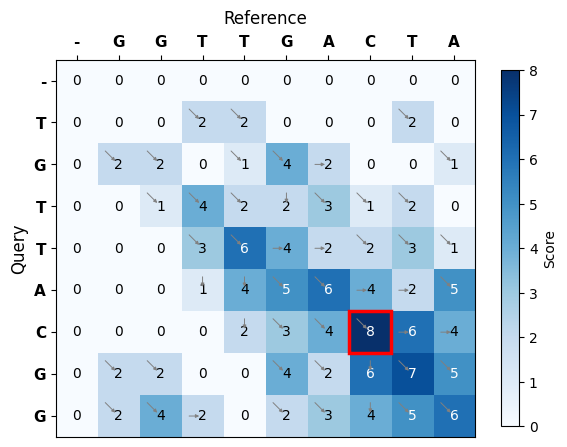

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

H = smith_waterman.constructMatrix(seqA, seqB)
arr = np.array(H)
max_i, max_j = smith_waterman.findHighestScore(H)
max_val = arr[max_i, max_j]

col_labels = ["-"] + list(seqB)
row_labels = ["-"] + list(seqA)

# ── precompute which neighbour each cell came from (single winner, same priority as the algorithm) ──
origins = {}  # (i,j) -> (di, dj)
for i in range(1, arr.shape[0]):
    for j in range(1, arr.shape[1]):
        if arr[i, j] == 0:
            continue
        diag = H[i-1][j-1] + (smith_waterman.matchScore if seqA[i-1] == seqB[j-1] else smith_waterman.mismatchScore)
        up   = H[i-1][j] + smith_waterman.gapScore
        left = H[i][j-1] + smith_waterman.gapScore
        if arr[i, j] == diag:
            origins[(i, j)] = (-1, -1)   # diagonal
        elif arr[i, j] == up:
            origins[(i, j)] = (-1, 0)    # up
        elif arr[i, j] == left:
            origins[(i, j)] = (0, -1)    # left

# ── Step 1: Scoring matrix with origin arrows + highest score ──
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(arr, cmap=plt.cm.Blues, aspect="equal")

# cell values
for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        val = arr[i, j]
        txt_color = "white" if val > max_val * 0.6 else "black"
        ax.text(j, i, str(val), ha="center", va="center", fontsize=10, color=txt_color)

# small gray arrow from source direction into cell
arrow_len = 0.32
for (i, j), (di, dj) in origins.items():
    x_start = j + dj * arrow_len
    y_start = i + di * arrow_len
    x_end   = j + dj * 0.08
    y_end   = i + di * 0.08
    ax.annotate("", xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle="-|>", color="gray",
                                lw=0.7, mutation_scale=5, shrinkA=0, shrinkB=0))

# highlight the highest-score cell
rect = Rectangle((max_j - 0.5, max_i - 0.5), 1, 1,
                 linewidth=2.5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11, fontweight="bold")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("Reference", fontsize=12, labelpad=8)
ax.set_ylabel("Query", fontsize=12)
plt.colorbar(im, ax=ax, label="Score", shrink=0.8)
fig.tight_layout()
plt.savefig("sw_step1_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

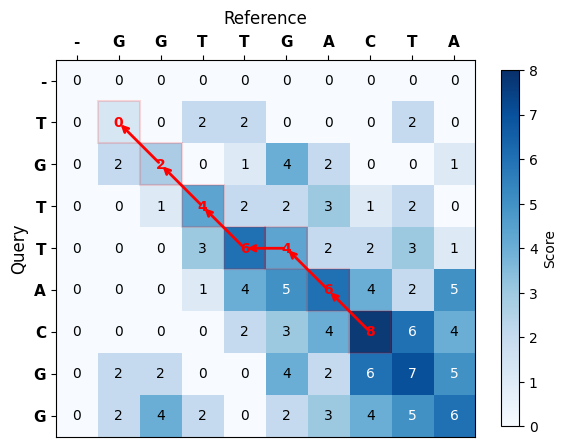

Aligned A: GTT-AC
Aligned B: GTTGAC
Score: 8, Identity: 83.3%


In [15]:
# ── Step 2: Traceback path ──

# reconstruct path
path = []
i, j = max_i, max_j
path.append((i, j))
while i > 0 and j > 0 and H[i][j] != 0:
    diag = H[i-1][j-1]
    up   = H[i-1][j]
    left = H[i][j-1]
    cur  = H[i][j]
    if cur == diag + (smith_waterman.matchScore if seqA[i-1] == seqB[j-1] else smith_waterman.mismatchScore):
        i -= 1; j -= 1
    elif cur == up + smith_waterman.gapScore:
        i -= 1
    elif cur == left + smith_waterman.gapScore:
        j -= 1
    else:
        break
    path.append((i, j))

path_set = set(path)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(arr, cmap=plt.cm.Blues, aspect="equal")

for i in range(arr.shape[0]):
    for j in range(arr.shape[1]):
        val = arr[i, j]
        in_path = (i, j) in path_set
        weight = "bold" if in_path else "normal"
        color = "red" if in_path else ("white" if val > max_val * 0.6 else "black")
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=10, fontweight=weight, color=color)

# highlight traceback cells
for (r, c) in path_set:
    rect = Rectangle((c - 0.5, r - 0.5), 1, 1,
                      linewidth=1.5, edgecolor="red", alpha=0.15)
    ax.add_patch(rect)

# draw arrows along the path
for k in range(len(path) - 1):
    r1, c1 = path[k]
    r2, c2 = path[k + 1]
    ax.annotate("", xy=(c2, r2), xytext=(c1, r1),
                arrowprops=dict(arrowstyle="->", color="red", lw=2))

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11, fontweight="bold")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("Reference", fontsize=12, labelpad=8)
ax.set_ylabel("Query", fontsize=12)
plt.colorbar(im, ax=ax, label="Score", shrink=0.8)
fig.tight_layout()
plt.savefig("sw_step2_traceback.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Aligned A: {alignedA}")
print(f"Aligned B: {alignedB}")
print(f"Score: {score}, Identity: {identity:.1f}%")

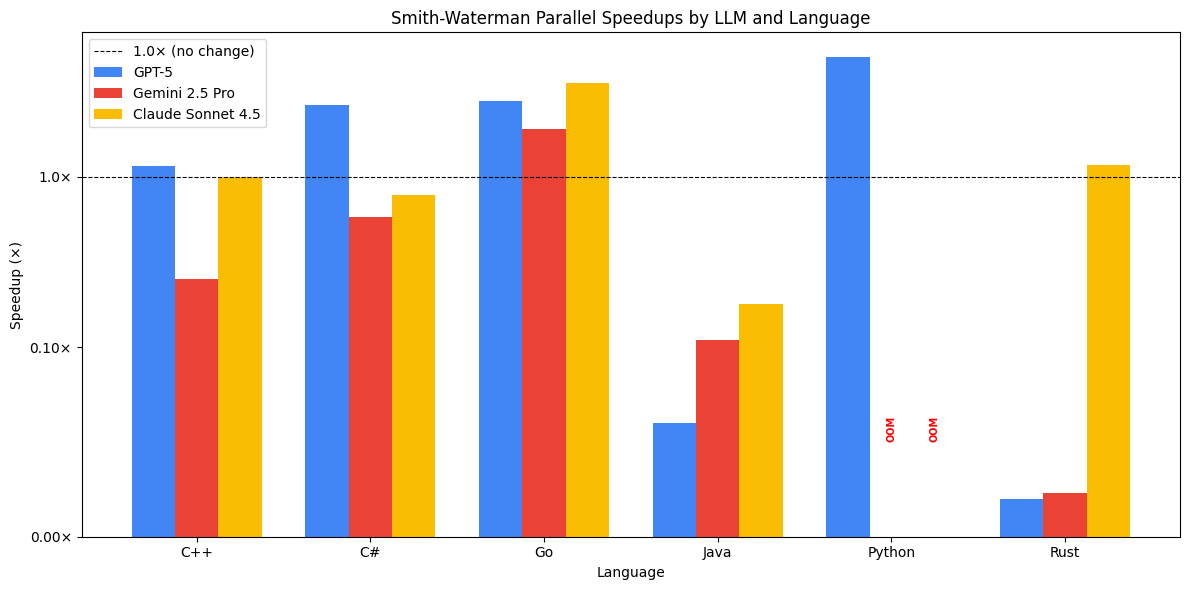

In [3]:
import matplotlib.pyplot as plt
import numpy as np

languages = ['C++', 'C#', 'Go', 'Java', 'Python', 'Rust']

# Speedup values (use np.nan for OOM/crash)
gpt5 =          [1.16, 2.62, 2.78, 0.06, 5.05, 0.02]
gemini =        [0.25, 0.58, 1.89, 0.11, np.nan, 0.023]
claude_sonnet = [1.0,  0.78, 3.52, 0.18, np.nan, 1.17]

x = np.arange(len(languages))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, gpt5, width, label='GPT-5', color='#4285F4')
bars2 = ax.bar(x, gemini, width, label='Gemini 2.5 Pro', color='#EA4335')
bars3 = ax.bar(x + width, claude_sonnet, width, label='Claude Sonnet 4.5', color='#FBBC04')

# Draw the 1.0x baseline
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=0.8, label='1.0× (no change)')

# Mark OOM/crash entries
crash_entries = [
    (4, 1, 'OOM'),       # Gemini Python
    (4, 2, 'OOM'),       # Claude Python
]
for lang_idx, llm_idx, label in crash_entries:
    x_pos = lang_idx + (llm_idx - 1) * width
    ax.text(x_pos, 0.05, label, ha='center', va='bottom', fontsize=7,
            fontweight='bold', color='red', rotation=90)

ax.set_ylabel('Speedup (×)')
ax.set_xlabel('Language')
ax.set_title('Smith-Waterman Parallel Speedups by LLM and Language')
ax.set_xticks(x)
ax.set_xticklabels(languages)
ax.set_yscale('symlog', linthresh=0.1)  # log scale handles the wide range (0.02 to 5.05)
ax.set_ylim(0, 7)
ax.legend(loc='upper left')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val:.2f}×' if val < 1 else f'{val:.1f}×'))

plt.tight_layout()
plt.savefig('sw_speedup_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
